In [2]:
from AgentBasedModel import *
from AgentBasedModel.params_calibration.utils_calibration import *
from AgentBasedModel.params_calibration.calibrationv3.utils_calibration_v2 import *
import random
import numpy as np
import optuna

In [3]:
# всякие константы для обучения
N_RUNS = 4
N_TICKS = 1000
EXCHANGE_VOLUME = 1000

target_params = pd.read_csv('mean_std_ethusdt_validation_data2.csv')
NORM_COEF_LR = 1 / target_params.loc[target_params["param"] == 'mean_on_ret2', "mean"].iloc[0]
W = pd.read_csv('weights(inv only diag).csv').to_numpy()

In [7]:
# метрика лосса: матрица ковариаций где осталась только диагональ
# + байесовское обучение оптуной, все диапазоны были выбраны обще (далее будут сужаться)
def loss_msm(t_params, m_params):
    num = ['mean_on_ret2', "std_on_ret2", "q1_on_ret2", "q5_on_ret2", "q95_on_ret2", "q99_on_ret2", "kurtosis_on_ret2", "skewness_on_ret", "autocorr_on_ret_1", "autocorr_on_ret_5", "autocorr_on_ret_10", "autocorr_on_abs_1", "autocorr_on_abs_5", "autocorr_on_abs_10"]
    errors = np.zeros((len(num), 1))
    id = -1
    for i in num:
        id += 1
        errors[id] = t_params.loc[t_params["param"] == i, "mean"].iloc[0] - m_params[i]
    ans = errors.T @ W @ errors
    # print(ans.shape)
    return float(ans[0][0])

def objective(trial):
    params = {
        'Random': trial.suggest_int('Random', 5, 100),
        'Fundamentalist': trial.suggest_int('Fundamentalist', 5, 100),
        'Chartist': trial.suggest_int('Chartist', 5, 100),
        'Universalist': trial.suggest_int('Universalist', 5, 100),
        'MarketMaker': trial.suggest_int('MarketMaker', 0, 1),
        'Transaction_cost': trial.suggest_float("Transaction_cost", 1e-4, 1e-1, log=True),
        'Std':  trial.suggest_float("Std", 1e-1, 1e2, log=True),
        'Std_Random':  trial.suggest_float("Std_Random", 1e-2, 1e1, log=True),
        'Avg_Traders': trial.suggest_float("Avg_Traders", -5, 0),
        'Last_Step': trial.suggest_float("Last_Step", 0, 1),
        'Last_Ret': trial.suggest_float("Last_Ret", 1e-3, 50, log=True),
        'Noisy_Level': trial.suggest_float("Noisy_Level", 1e-3, 5, log=True)
    }
    errors = []

    for run_idx in range(N_RUNS):
        random.seed(42 + run_idx)
        np.random.seed(42 + run_idx)

        try:
            exchange = ExchangeAgent(std=params['Std'], transaction_cost=params['Transaction_cost'], std_random=params['Std_Random'])
            simulator2 = Simulator(**{
                'exchange': exchange,
                'traders': [
                    *[Random(exchange, EXCHANGE_VOLUME) for _ in range(params['Random'])],
                    *[Fundamentalist(exchange, EXCHANGE_VOLUME) for _ in range(params['Fundamentalist'])],
                    *[Chartist(exchange, EXCHANGE_VOLUME) for _ in range(params['Chartist'])],
                    *[Universalist(exchange, EXCHANGE_VOLUME) for _ in range(params['Universalist'])],
                    *[MarketMaker(exchange, EXCHANGE_VOLUME) for _ in range(params['MarketMaker'])],
                ],
            }, avg_traders=params['Avg_Traders'], last_step=params['Last_Step'], last_ret=params['Last_Ret'], noisy_level=params['Noisy_Level'], norm_coef_lr=NORM_COEF_LR)

            simulator2.simulate(N_TICKS, silent=True)
            prices = np.array(simulator2.info.prices)
            model_params = pipeline(prices, is_print=0)
            errors.append(loss_msm(target_params, model_params))
        except Exception as e:
            print("Run failed:", run_idx, e)
            continue

    if len(errors) != N_RUNS:
        return 100000
    return float(np.mean(errors))

In [8]:
# само обучение
study_msm = optuna.create_study(study_name="calibration_mse(exchange_volume=1000)2", direction="minimize", storage="sqlite:///calibration_mse(exchange_volume=1000)2.db",  load_if_exists=True)
study_msm.optimize(objective, show_progress_bar=True, n_trials=500)

best_params = study_msm.best_params
best_score = study_msm.best_value
print('Best params:', best_params)
print('Best Score:', best_score)

[I 2026-04-26 13:59:07,345] A new study created in RDB with name: calibration_mse(exchange_volume=1000)2
Best trial: 0. Best value: 1926.82:   0%|          | 1/500 [00:04<36:38,  4.41s/it]

[I 2026-04-26 13:59:11,747] Trial 0 finished with value: 1926.820831432831 and parameters: {'Random': 75, 'Fundamentalist': 87, 'Chartist': 16, 'Universalist': 11, 'MarketMaker': 0, 'Transaction_cost': 0.03210365449407829, 'Std': 0.8167624002327106, 'Std_Random': 6.269802840761994, 'Avg_Traders': -3.81827872863994, 'Last_Step': 0.9026833119277826, 'Last_Ret': 0.020548598522204788, 'Noisy_Level': 0.0027258925163082255}. Best is trial 0 with value: 1926.820831432831.


Best trial: 0. Best value: 1926.82:   0%|          | 2/500 [02:49<13:42:11, 99.06s/it]

[I 2026-04-26 14:01:57,065] Trial 1 finished with value: 2189.3028466639257 and parameters: {'Random': 69, 'Fundamentalist': 82, 'Chartist': 34, 'Universalist': 79, 'MarketMaker': 1, 'Transaction_cost': 0.04788667134000745, 'Std': 4.478104257197046, 'Std_Random': 5.710618973056393, 'Avg_Traders': -4.162901927426651, 'Last_Step': 0.1006852157128777, 'Last_Ret': 9.488527024866992, 'Noisy_Level': 0.06530221123737419}. Best is trial 0 with value: 1926.820831432831.


Best trial: 0. Best value: 1926.82:   1%|          | 3/500 [03:02<8:16:02, 59.88s/it] 

...

[I 2026-04-26 15:17:04,171] Trial 497 finished with value: 22.377106704187113 and parameters: {'Random': 94, 'Fundamentalist': 8, 'Chartist': 96, 'Universalist': 5, 'MarketMaker': 1, 'Transaction_cost': 0.0014472811931867285, 'Std': 1.9943490648566617, 'Std_Random': 0.513611966919193, 'Avg_Traders': -2.5993481123461444, 'Last_Step': 0.4823451752260913, 'Last_Ret': 0.03931795160089116, 'Noisy_Level': 0.2548131004246357}. Best is trial 226 with value: 7.344547255586129.


Best trial: 226. Best value: 7.34455: 100%|█████████▉| 499/500 [1:18:06<00:08,  8.39s/it]

[I 2026-04-26 15:17:14,183] Trial 498 finished with value: 39.60544219770962 and parameters: {'Random': 97, 'Fundamentalist': 12, 'Chartist': 85, 'Universalist': 21, 'MarketMaker': 1, 'Transaction_cost': 0.0017060371527811366, 'Std': 4.483055077399021, 'Std_Random': 0.2940853844275315, 'Avg_Traders': -2.780775903460478, 'Last_Step': 0.3808277355417978, 'Last_Ret': 0.26337000921617676, 'Noisy_Level': 0.20578096176734473}. Best is trial 226 with value: 7.344547255586129.


Best trial: 226. Best value: 7.34455: 100%|██████████| 500/500 [1:18:15<00:00,  9.39s/it]

[I 2026-04-26 15:17:23,316] Trial 499 finished with value: 13.061367797531068 and parameters: {'Random': 89, 'Fundamentalist': 7, 'Chartist': 97, 'Universalist': 13, 'MarketMaker': 1, 'Transaction_cost': 0.0013395845464355355, 'Std': 1.8226722880833648, 'Std_Random': 0.4275314283562752, 'Avg_Traders': -2.4678020510279732, 'Last_Step': 0.3422738926120621, 'Last_Ret': 0.0015291233379893358, 'Noisy_Level': 0.1524204420987348}. Best is trial 226 with value: 7.344547255586129.
Best params: {'Random': 93, 'Fundamentalist': 10, 'Chartist': 98, 'Universalist': 7, 'MarketMaker': 1, 'Transaction_cost': 0.0011531906004078228, 'Std': 1.3080203958589853, 'Std_Random': 0.476717567192235, 'Avg_Traders': -2.5616113782902223, 'Last_Step': 0.3122812649247898, 'Last_Ret': 0.03270200551850368, 'Noisy_Level': 0.205031673861624}
Best Score: 7.344547255586129


[I 2026-04-27 02:01:58,301] Using an existing study with name 'calibration_mse(exchange_volume=1000)2' instead of creating a new one.
C:\Users\rodion\AppData\Local\Temp\ipykernel_20672\1387587129.py:5: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study_msm)


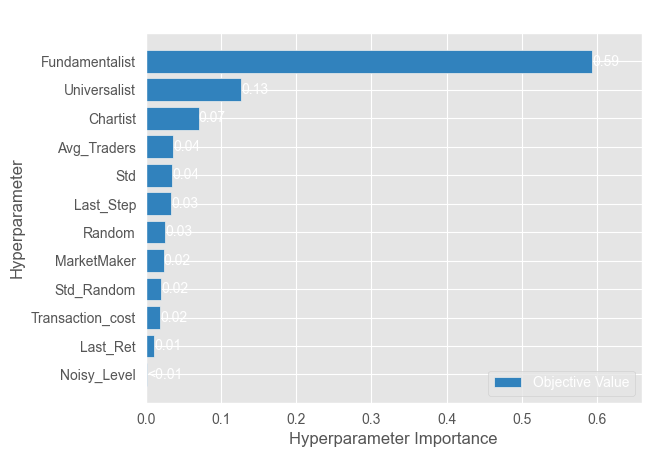

In [10]:
from optuna.visualization.matplotlib import plot_param_importances
import sklearn

study_msm = optuna.create_study(study_name="calibration_mse(exchange_volume=1000)2", direction="minimize", storage="sqlite:///calibration_mse(exchange_volume=1000)2.db",  load_if_exists=True)
plot_param_importances(study_msm)
plt.show()

In [ ]:
best_params = study_msm.best_params
best_score = study_msm.best_value
print('Best params:', best_params)
print('Best Score:', best_score)

C:\Users\rodion\AppData\Local\Temp\ipykernel_20672\1604666724.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax = plot_param_importances(study_msm)


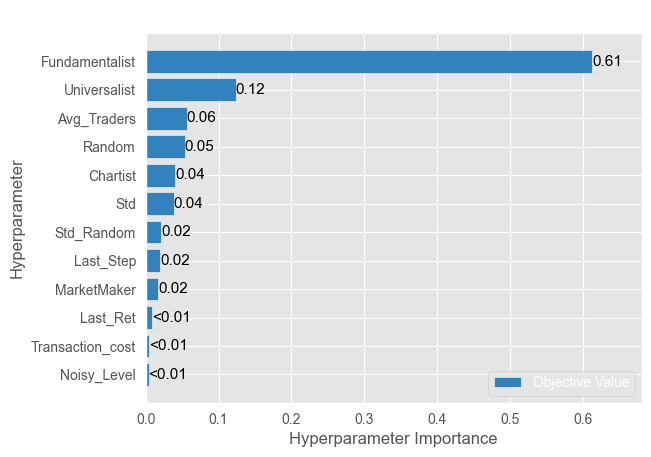

In [12]:
ax = plot_param_importances(study_msm)
for txt in ax.texts:
    txt.set_color("black")   # можно "yellow", "red", "#ffffff" и т.д.
    txt.set_fontsize(11)

plt.show()